In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from numpy.polynomial.polynomial import polyfit
# import statsmodels.api as sm # import statsmodels 
import scipy

In [39]:
adata = sc.read("/rds/project/bg200/rds-bg200-hphi-gottgens/users/mb2338/nestorowa_velocity/subsetted_adata.h5") #unnorm, disrete counts, selected cells

In [41]:
adata.obs

,LTHSC_broad,LMPP_broad,MPP_broad,CMP_broad,MEP_broad,GMP_broad,MPP1_broad,MPP2_broad,MPP3_broad,STHSC_broad,...,MPP1,MPP2,MPP3,STHSC,ESLAM,HSC1,Projected,n_genes,percent_mito,n_counts
HSPC_001,False,False,True,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,6226,0.036312,2704388.0
HSPC_002,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,5028,0.050438,254254.0
HSPC_003,False,False,True,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,6828,0.069990,1342284.0
HSPC_004,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,6035,0.061287,658310.0
HSPC_006,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,6697,0.087861,734634.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Prog_848,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,6430,0.060212,402047.0
Prog_849,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,6586,0.064027,491421.0
Prog_850,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,8417,0.079938,1205090.0
Prog_851,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,7200,0.093534,685192.0


In [42]:
scv.pp.filter_and_normalize(adata,min_shared_counts = 20,n_top_genes=5000)
scv.pp.moments(adata,n_neighbors=30)

Filtered out 40106 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Exctracted 5000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [51]:
# Extract spliced dataframe
mat_s = pd.DataFrame(adata.layers['Ms'])
mat_s.index = adata.obs_names
mat_s.columns = adata.var_names

In [52]:
# Extract unspliced dataframe
mat_u = pd.DataFrame(adata.layers['Ms'])
mat_u.index = adata.obs_names
mat_u.columns = adata.var_names

In [53]:
df_sl = pd.DataFrame(index = adata.var_names) # slope
df_db = pd.DataFrame(index = adata.var_names) # error on slope
df_int = pd.DataFrame(index = adata.var_names) # intercept

In [54]:
sum_s = pd.DataFrame(np.sum(mat_s,axis =1))
sum_u = pd.DataFrame(np.sum(mat_u,axis =1))

In [56]:
# compute slopes
for pop in adata.obs.columns[:22]:
    print(pop)
    vec = adata.obs[pop]
    
    x = mat_s.loc[vec]
    y = mat_u.loc[vec]
    
    mx = np.mean(x)
    my = np.mean(y)
    x_mx = x - mx
    y_my = y - my
    xy = np.sum(x_mx * y_my, axis = 0)
    X2 = np.sum(x_mx**2,axis = 0)
    sl = xy / X2
    inter = my - sl * mx
    n = np.sum(vec)
                
    df_sl[pop] = pd.DataFrame(sl)
    df_int[pop] = pd.DataFrame(inter)
                
    pred = sl * x + inter
    sse = (pred - y)**2
    SSE = np.sum(sse, axis = 0)
                
    db = np.sqrt(SSE/(n-2)/X2)
    df_db[pop] = pd.DataFrame(db)

LTHSC_broad
LMPP_broad
MPP_broad
CMP_broad
MEP_broad
GMP_broad
MPP1_broad
MPP2_broad
MPP3_broad
STHSC_broad
LTHSC
LMPP
MPP
CMP
MEP
GMP
MPP1
MPP2
MPP3
STHSC
ESLAM
HSC1


In [62]:
frames = [df_sl,df_db]
df_bu = pd.concat(frames)

In [63]:
#df_bu.to_csv('df_slopes_scv_pipe.csv')

In [64]:
# quantile dataframe
df_quan = pd.DataFrame(index=adata.var_names)

for pop in adata.obs.columns[:22]:
    n = np.sum(adata.obs[pop])
    
    df_quan[pop] = scipy.stats.t.ppf(0.95, n - 1)

In [65]:
# confidence bounds
df_conf = df_db * df_quan

In [66]:
df_min = df_sl - df_conf
df_max = df_sl + df_conf

In [67]:
df_M = np.max(df_min,axis = 1)

In [68]:
df_comp = pd.concat([pd.DataFrame(df_M)]*22,axis = 1)
df_comp.columns = df_sl.columns

In [95]:
df_log = df_min *0

In [70]:
df_log[df_max - df_comp >=0] =1

In [71]:
df_log

,LTHSC_broad,LMPP_broad,MPP_broad,CMP_broad,MEP_broad,GMP_broad,MPP1_broad,MPP2_broad,MPP3_broad,STHSC_broad,...,MPP,CMP,MEP,GMP,MPP1,MPP2,MPP3,STHSC,ESLAM,HSC1
Vcpip1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Arfgef1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Cpa6,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0
Slco5a1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Ncoa2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ap1s2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Tmem27,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0
Piga,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Gpm6b,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


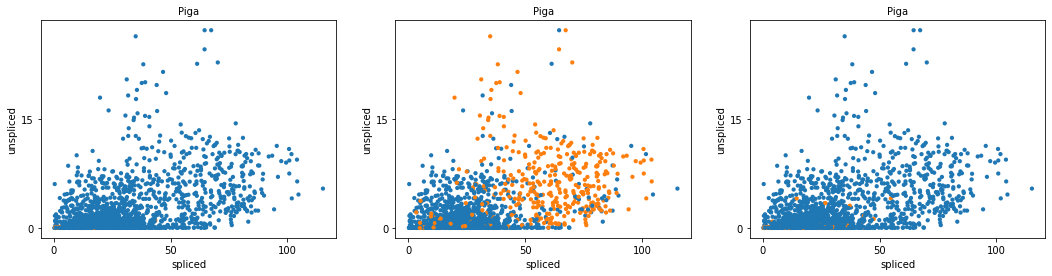

In [81]:
scv.pl.scatter(adata,basis='Piga',color=['ESLAM','MEP_broad', 'HSC1'])